In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
import os
os.getcwd()

'c:\\Users\\ankit\\OneDrive\\Desktop\\admission-accuracy-improvement\\notebooks'

In [13]:
df = pd.read_csv("../data/admission_predict.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [14]:
df.shape

(500, 9)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [16]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['Serial_No.', 'GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance_of_Admit'],
      dtype='object')

In [17]:
df = df.drop(columns=["Serial_No."])

In [18]:
X = df.drop(columns=["Chance_of_Admit"])
y = df["Chance_of_Admit"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((400, 7), (100, 7))

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = lr_model.predict(X_test)

In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

rmse, mae, mape, r2

(np.float64(0.0608658804157831),
 0.04272265427705369,
 np.float64(6.857756648317821),
 0.8188432567829629)

In [23]:
print(f"Baseline RMSE : {rmse:.4f}")
print(f"Baseline MAE  : {mae:.4f}")
print(f"Baseline MAPE : {mape:.2f}%")
print(f"Baseline R²   : {r2:.4f}")

Baseline RMSE : 0.0609
Baseline MAE  : 0.0427
Baseline MAPE : 6.86%
Baseline R²   : 0.8188


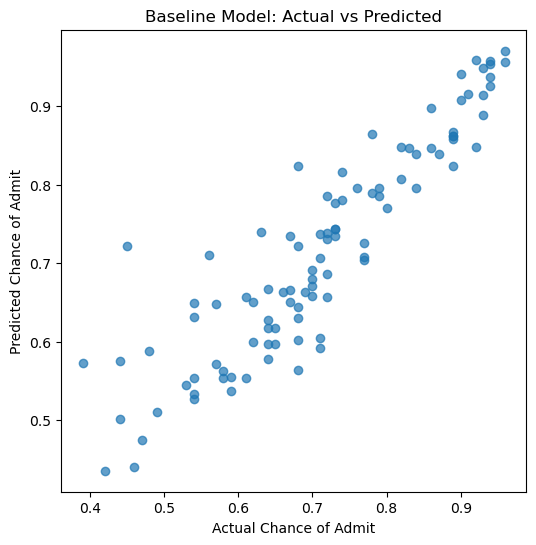

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Baseline Model: Actual vs Predicted")
plt.show()